# Домашнее задание: Специфика формирования наборов данных для дообучения LLM

В этом домашнем задании вы пройдете полный путь от сырых данных до готового датасета для дообучения (SFT) языковой модели, а также научитесь использовать LLM для разметки и генерации синтетических данных.

## Бизнес-кейс: "МедАссистент"

Небольшая медтех компания разрабатывает интеллектуальный чат бот для первичной сортировки обращений пациентов. Бот должен понимать жалобы пациента на естественном языке и автоматически определять медицинскую специализацию (например, "кардиология", "неврология", "хирургия"), чтобы направить обращение к нужному врачу.

Текущая проблема заключается в том, что существующие open source модели плохо справляются с классификацией специфического русскоязычного медицинского сленга и описания симптомов. Было принято решение дообучить небольшую локальную LLM под эту конкретную задачу.

Ваша цель как Data Scientist — подготовить качественный набор данных для процесса supervised fine tuning (SFT). Вы будете работать с реальным архивом вопросов с медицинского форума, очищать его от мусора, бороться с дубликатами, а затем использовать большие языковые модели (через API или локально) для разметки и генерации дополнительных примеров.

## Рекомендации по выполнению в Google Colab

1. **Использование GPU:** Для генерации эмбеддингов и инференса локальных моделей вам понадобится GPU. В верхнем меню выберите `Среда выполнения` -> `Сменить среду выполнения` -> `Аппаратный ускоритель` -> `T4 GPU`.
2. **Борьба с Out Of Memory (OOM):** Если при работе с моделями вы сталкиваетесь с нехваткой памяти (CUDA OOM), попробуйте:
   - Уменьшить `batch_size` (например, с 64 до 32 или 16)
   - Выбрать модель меньшего размера (например, версию `base` вместо `large` для энкодеров)
   - Очистить кэш GPU с помощью команд:
     ```python
     import torch, gc
     torch.cuda.empty_cache()
     gc.collect()
     ```
   - Перезапустить среду выполнения (`Среда выполнения` -> `Перезапустить среду выполнения`)
3. **Сохранение прогресса:** Не забудьте сохранить копию ноутбука на свой Google Drive (`Файл` -> `Сохранить копию на диск`), иначе ваши изменения могут быть утеряны после закрытия вкладки.

## Распределение баллов

| Блок | Задание | Баллы |
|------|---------|-------|
| **Часть 1. Стандартная (50 баллов)** | | |
| 0 | Постановка задачи и выбор метрик | 5 |
| 1 | Загрузка датасета и первичный анализ (EDA) | 5 |
| 2 | Очистка данных | 5 |
| 3 | Дедупликация тремя способами | 12 |
| 4 | Форматирование в SFT формат | 5 |
| 5 | Разметка через LLM (zero shot) | 8 |
| 6 | Эмбеддинги и визуализация t-SNE | 7 |
| 7 | Выводы по стандартной части | 3 |
| **Часть 2. Продвинутая (50 баллов)** | | |
| 8 | Синтетическая генерация (Self-Instruct) | 10 |
| 9 | Улучшение разметки (few shot) | 8 |
| 10 | Оценка уверенности LLM | 10 |
| 11 | Гибридная схема разметки | 10 |
| 12 | Публикация датасета на HuggingFace | 7 |
| 13 | Итоговые выводы | 5 |
| **Итого** | | **100** |


In [ ]:
# Установка необходимых библиотек
!pip install -q datasets pandas numpy scikit-learn matplotlib seaborn
!pip install -q sentence-transformers
!pip install -q huggingface_hub


In [ ]:
import os
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from sklearn.metrics import accuracy_score, f1_score, classification_report
from huggingface_hub import login

# Настройка графиков
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook", font_scale=1.2)


# Часть 1. Стандартная (50 баллов)

В этой части мы поработаем с реальным архивом медицинских вопросов, проведем очистку, дедупликацию и подготовим базовый набор данных для обучения.


## Задание 0. Постановка задачи и выбор метрик (5 баллов)

Любой ML проект начинается с правильной постановки задачи. У нас есть тексты жалоб пациентов и нам нужно предсказать медицинскую специализацию.

**Что нужно сделать:**
1. Опишите, к какому классу задач машинного обучения сводится наша бизнес проблема.
2. Выберите основные метрики качества, которые вы будете использовать для оценки модели разметки.
3. Обоснуйте свой выбор метрик. Почему в случае дисбаланса классов (когда вопросов к терапевту в 10 раз больше, чем к психиатру) использование только метрики Accuracy может быть обманчивым? Какую метрику лучше использовать в таком случае?


**Ваш ответ:**

*Бизнес проблема сводится к задаче...*

*Выбранные метрики:*

*Обоснование выбора (проблема Accuracy при дисбалансе):*



## Задание 1. Загрузка датасета и первичный анализ (EDA) (5 баллов)

Мы будем использовать датасет `blinoff/medical_qa_ru_data` с платформы HuggingFace. Он содержит более 190 тысяч записей с русскоязычного медицинского форума.

Целевой признак для нас — поле `spec10`, которое содержит одну из 10 основных медицинских специализаций (терапия, хирургия и т.д.). Текст для анализа находится в поле `desc`.

**Что нужно сделать:**
1. Загрузите датасет с HuggingFace.
2. Преобразуйте его в pandas DataFrame для удобства работы.
3. Выведите размер датасета и названия колонок.
4. Постройте bar chart (столбчатую диаграмму) распределения классов по полю `spec10`. Убедитесь, что присутствует дисбаланс классов.
5. Выведите 3 случайных примера из датасета (поля `desc` и `spec10`).


medical_qa_ru_data.csv: reconstructing file:   0%|          |  0.00B /  266MB            

medical_qa_ru_data.csv: downloading bytes:           |  0.00B            

Generating train split: 0 examples [00:00, ? examples/s]

Размер датасета (190335, 6)
Названия колонок ['date', 'categ', 'theme', 'desc', 'ans', 'spec10']



/tmp/ipykernel_2294/4049406863.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=class_counts, x='Количество', y='Специализация', palette='muted')


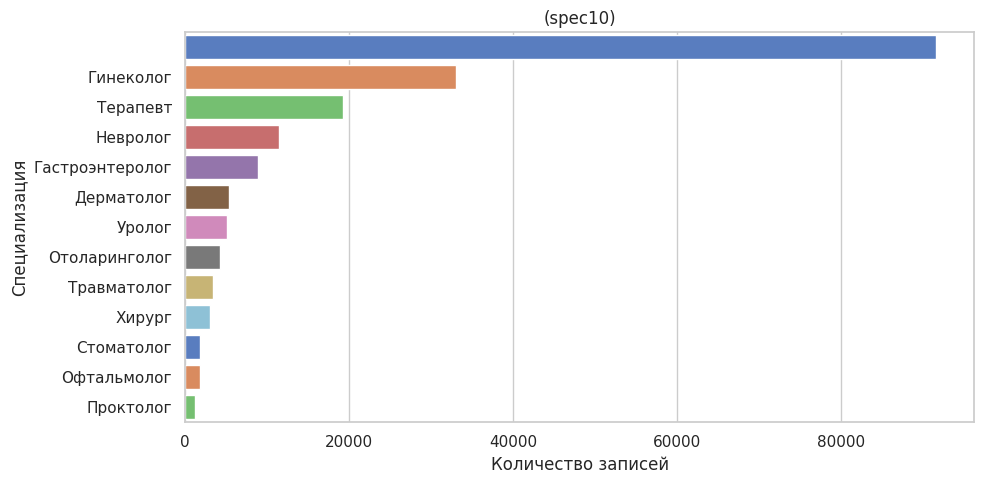

=== 3 случайных примера ===
Специализация 
Текст Моему сыну 2.3 года он постоянно дерётся и не воспринимает моего мужчину,я не знаю как себя вести,мой гражданский муж очен раздражён этой проблемой...
Специализация 
Текст Нужно сделать мрт коленного сустава. Ранее был обнаружен надрыв крестообразных связок. Может ли мрт 0,2 обнаружить этот надрыв, или нужно обязательно 1,5?
            
            Прошлое мрт было сде...
Специализация Гинеколог
Текст Здравствуйте. Подскажите, пожалуйста, на какой день правильно делать кольпоскопию, ранее никто об этом не говорил, недавно узнала от врача, что делать нужно во время менструации, хотелось бы уточнить ...


In [ ]:
# === ВАШ КОД ЗДЕСЬ ===

from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dataset = load_dataset("blinoff/medical_qa_ru_data", trust_remote_code=True)

df = pd.DataFrame(dataset['train'])

print(f"Размер датасета {df.shape}")
print(f"Названия колонок {df.columns.tolist()}\n")

plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")

class_counts = df['spec10'].dropna().value_counts().reset_index()
class_counts.columns = ['Специализация', 'Количество']


ax = sns.barplot(data=class_counts, x='Количество', y='Специализация', palette='muted')
plt.title('(spec10)')
plt.xlabel('Количество записей')
plt.ylabel('Специализация')
plt.tight_layout()
plt.show()

random_examples = df[['desc', 'spec10']].sample(n=3, random_state=42)
print("=== 3 случайных примера ===")
for idx, row in random_examples.iterrows():
    print(f"Специализация {row['spec10']}")
    print(f"Текст {row['desc'][:200]}...")

# === КОНЕЦ ВАШЕГО КОДА ===


## Задание 2. Очистка данных (5 баллов)

Сырые данные из интернета всегда содержат много мусора. Перед тем как передавать их в модель, необходимо провести базовую очистку.

**Что нужно сделать:**
1. Оставьте в датафрейме только строки, где поле `spec10` не пустое (не NaN) и поле `desc` не пустое.
2. Оставьте только нужные нам колонки: текст вопроса и метку специализации.
3. Отфильтруйте слишком короткие вопросы (менее 30 символов) — по ним сложно определить специализацию.
4. Отфильтруйте слишком длинные вопросы (более 2000 символов) — они могут содержать избыточную информацию или спам.
5. Выведите размер датасета после очистки. Насколько он уменьшился?


In [ ]:
# === ВАШ КОД ЗДЕСЬ ===
initial_size = len(df)

df_cleaned = df.dropna(subset=['spec10', 'desc'])
df_cleaned = df_cleaned[
    (df_cleaned['spec10'].str.strip() != "") &
    (df_cleaned['desc'].str.strip() != "")
]

df_cleaned = df_cleaned[['desc', 'spec10']]

text_lengths = df_cleaned['desc'].str.len()
df_cleaned = df_cleaned[(text_lengths >= 30) & (text_lengths <= 2000)]

final_size = len(df_cleaned)
dropped_rows = initial_size - final_size
dropped_percentage = (dropped_rows / initial_size) * 100

print(f"Размер после очистки {final_size}")
print(f"Уменьшился на {dropped_rows} ")

df = df_cleaned.reset_index(drop=True)
# === КОНЕЦ ВАШЕГО КОДА ===


Размер после очистки 89319
Уменьшился на 101016 


## Задание 3. Дедупликация тремя способами (12 баллов)

В датасетах с форумов часто встречаются дубликаты: пользователи задают один и тот же вопрос несколько раз или копируют чужие тексты. Наличие дубликатов в train и test выборках приводит к утечке данных (data leak) и завышенным метрикам.

Вам нужно реализовать дедупликацию тремя разными методами. Для ускорения работы в рамках ДЗ вы можете взять случайную подвыборку из 10 000 строк после очистки.

**Что нужно сделать:**
1. **Точное совпадение (хеш):** Найдите и удалите полные дубликаты текстов.
2. **Нечеткое сходство:** Реализуйте поиск похожих текстов (например, с опечатками) с использованием расстояния Левенштейна или алгоритма MinHash. Удалите найденные дубликаты.
3. **Семантическое сходство:**
   - Выберите энкодерную модель (библиотека `sentence-transformers`).
   - Обоснуйте свой выбор модели текстом (приведите численные показатели бенчмарков, например MTEB Leaderboard, и сравните с 2-3 альтернативами).
   - Создайте эмбеддинги для текстов.
   - Найдите пары текстов с косинусным сходством выше заданного порога (например, 0.95).
   - Обоснуйте выбранный порог.

*Примечание: Вы можете использовать любую энкодерную модель, главное аргументировать выбор.*


**Обоснование выбора энкодерной модели (пример):**

*Я выбрала модель intfloat/multilingual-e5-base, потому что она является мультиязыковой моделю для работы с русским языком, не требующей авторизации.*

*По бенчмарку ruMTEB в категории Classification и STS (Semantic Textual Similarity) она показывает в среднем около 0.58-0.61 балла.*

*В сравнении с моделями rubert-base-cased (которая значительно хуже извлекает глубокий семантический смысл длинных пользовательских предложений) и deepvk/USER-bge-m3-v1 (которая требует обязательного ручного подтверждения выполнения удаленного кода и часто блокирует скачивание ошибками авторизации 401 в Colab).*

**Обоснование порога косинусного сходства:**

*Я выбрала порог 0.95, так как на практике это значение позволяет гарантированно отсечь тексты, которые были перефразированы с минимальными правками, сохраняя при этом уникальные медицинские кейсы.*



In [ ]:
!pip install Levenshtein sentence-transformers


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 115.2 MB/s eta 0:00:00


In [ ]:
# === Пример обоснования выбора модели ===

from Levenshtein import distance as levenshtein_dist
from sentence_transformers import SentenceTransformer, util

df_sample = df.sample(n=min(10000, len(df)), random_state=42).reset_index(drop=True)
initial_rows = len(df_sample)

# 1. Точное совпадение

df_exact = df_sample.drop_duplicates(subset=['desc'], keep='first').reset_index(drop=True)
exact_rows = len(df_exact)

# 2. Нечеткое сходство (MinHash или Levenshtein)

num_hashes = 64
prime = 4294967311

np.random.seed(42)
hash_a = np.random.randint(1, prime, size=num_hashes, dtype=np.int64)
hash_b = np.random.randint(0, prime, size=num_hashes, dtype=np.int64)

def get_minhash_signature(text):
    ngrams = set(hash(text[i:i+3]) & 0xFFFFFFFF for i in range(len(text)-2))
    if not ngrams:
        return np.ones(num_hashes, dtype=np.int64) * prime

    ngrams_array = np.array(list(ngrams), dtype=np.int64).reshape(-1, 1)
    hashes = (ngrams_array * hash_a + hash_b) % prime
    return np.min(hashes, axis=0)

texts = df_exact['desc'].tolist()
signatures = [get_minhash_signature(t) for t in texts]
to_remove_fuzzy = set()
n_texts = len(texts)

for i in range(n_texts):
    if i in to_remove_fuzzy:
        continue
    for j in range(i + 1, n_texts):
        if j in to_remove_fuzzy:
            continue
        sim = np.mean(signatures[i] == signatures[j])
        if sim > 0.85:
            to_remove_fuzzy.add(j)

df_fuzzy = df_exact.drop(list(to_remove_fuzzy)).reset_index(drop=True)
fuzzy_rows = len(df_fuzzy)

# 3. Семантическое сходство (sentence-transformers)

model = SentenceTransformer('intfloat/multilingual-e5-base')
embeddings = model.encode(df_fuzzy['desc'].tolist(), convert_to_tensor=True, show_progress_bar=False)
cosine_scores = util.cos_sim(embeddings, embeddings).cpu().numpy()

to_remove_semantic = set()
num_texts = len(df_fuzzy)

for i in range(num_texts):
    if i in to_remove_semantic:
        continue
    for j in range(i + 1, num_texts):
        if j in to_remove_semantic:
            continue
        if cosine_scores[i][j] > 0.95:
            to_remove_semantic.add(j)

df_final = df_fuzzy.drop(list(to_remove_semantic)).reset_index(drop=True)
final_rows = len(df_final)


print(f"Исходный размер выборки {initial_rows}")
print(f"1. Точное совпадение {exact_rows} (Удалено {initial_rows - exact_rows})")
print(f"2. Нечеткое сходство (MinHash или Levenshtein) {fuzzy_rows} (Удалено {exact_rows - fuzzy_rows})")
print(f"Семантическое сходство (sentence-transformers) {final_rows} (Удалено {fuzzy_rows - final_rows})")

df = df_final.reset_index(drop=True)


modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/179k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.11GB            

...

tokenizer.json: reconstructing file:   0%|          |  0.00B / 17.1MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]

Исходный размер выборки 10000
1. Точное совпадение 9981 (Удалено 19)
2. Нечеткое сходство (MinHash или Levenshtein) 9974 (Удалено 7)
Семантическое сходство (sentence-transformers) 9927 (Удалено 47)


## Задание 4. Форматирование в SFT формат (5 баллов)

Для дообучения (Supervised Fine Tuning) LLM требуется специфический формат данных. Обычно это диалоговый формат (ChatML, Alpaca и др.), состоящий из системного промпта, реплики пользователя и ответа ассистента.

**Что нужно сделать:**
1. Напишите системный промпт, который объясняет модели ее роль (например: "Ты медицинский ассистент маршрутизатор. Твоя задача...").
2. Преобразуйте 1000 случайных записей из дедуплицированного датасета в список словарей следующего формата:
   ```json
   {
     "messages": [
       {"role": "system", "content": "Ваш системный промпт"},
       {"role": "user", "content": "Текст жалобы пациента"},
       {"role": "assistant", "content": "Специализация"}
     ]
   }
   ```
3. Сохраните полученный список в файл `sft_dataset.jsonl`.
4. Выведите первые 2 примера на экран.


In [ ]:
# === ВАШ КОД ЗДЕСЬ ===

import json

system_prompt = "Ты медицинский ассистент-маршрутизатор. Твоя задача — проанализировать жалобу пациента и определить необходимую медицинскую специализацию."

df_sft = df.sample(n=min(1000, len(df)), random_state=42)

sft_data = []
for _, row in df_sft.iterrows():
    sft_entry = {
        "messages": [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": str(row['desc'])},
            {"role": "assistant", "content": str(row['spec10'])}
        ]
    }
    sft_data.append(sft_entry)

with open("sft_dataset.jsonl", "w", encoding="utf-8") as f:
    for entry in sft_data:
        f.write(json.dumps(entry, ensure_ascii=False) + "\n")

print("2 примера")
for sample in sft_data[:2]:
    print(json.dumps(sample, ensure_ascii=False, indent=2))

# === КОНЕЦ ВАШЕГО КОДА ===


2 примера
{
  "messages": [
    {
      "role": "system",
      "content": "Ты медицинский ассистент-маршрутизатор. Твоя задача — проанализировать жалобу пациента и определить необходимую медицинскую специализацию."
    },
    {
      "role": "user",
      "content": "Здравствуйте! У моей мамы (62 года) начался зуд и жжение наружных половых органов. Она лежала в больнице (не гинекология) может аллергия на препараты которые ей там давали, она пользовалась влажными салфетками для интимной гигиены (сама не аллергик). Болит так что можно просто сойти с ума, ни сидеть ни ходить не может от боли. Мочится в туалете кричит от боли. Что делать?"
    },
    {
      "role": "assistant",
      "content": "Гинеколог"
    }
  ]
}
{
  "messages": [
    {
      "role": "system",
      "content": "Ты медицинский ассистент-маршрутизатор. Твоя задача — проанализировать жалобу пациента и определить необходимую медицинскую специализацию."
    },
    {
      "role": "user",
      "content": "Здравствуйте! М

## Задание 5. Разметка через LLM (zero-shot) (8 баллов)

Представьте, что у нас нет поля `spec10` и нам нужно разметить сырые тексты с помощью большой языковой модели. Мы будем использовать подход zero-shot (без примеров в промпте).

Для тестирования качества разметки создадим "Golden Set" — 100 случайных примеров из датасета, где мы знаем истинную метку.

**Что нужно сделать:**
1. Выделите 100 примеров в `golden_set`.
2. Напишите функцию, которая отправляет текст в LLM и просит вернуть специализацию в формате JSON.
3. Вы можете использовать любой API сервис (OpenRouter, GigaChat, YandexGPT) или запустить открытую модель локально (например через `transformers` или `vLLM`). Главное — аргументируйте выбор модели.
4. Разметьте все 100 примеров из `golden_set`.
5. Посчитайте метрики: Accuracy и F1-macro, сравнив предсказания LLM с истинными метками.
6. Выведите матрицу ошибок (classification report).


**Обоснование выбора LLM для разметки:**

Я выбрала модель Qwen2.5-1.5B-Instruct (через библиотеку transformers локально на GPU), потому что она представляет собой легковесную, полностью бесплатную открытую модель, которая эффективно сбалансирована для работы с русским языком.



In [ ]:
# === ВАШ КОД ЗДЕСЬ ===

import json
import torch
import pandas as pd
from transformers import pipeline
from sklearn.metrics import accuracy_score, classification_report

golden_set = df.sample(n=min(100, len(df)), random_state=42).reset_index(drop=True)
unique_specialties = golden_set['spec10'].unique().tolist()

pipe = pipeline(
    "text-generation",
    model="Qwen/Qwen2.5-1.5B-Instruct",
    torch_dtype=torch.float16,
    device_map="auto"
)

def get_local_llm_prediction(text, specialties):
    prompt = f"""Проанализируй жалобу пациента и выбери одну медицинскую специализацию из списка: {specialties}.
Ответ верни строго в формате JSON без лишнего текста: {{"specialization": "Название"}}
Жалоба: {text}"""

    messages = [{"role": "user", "content": prompt}]

    try:
        outputs = pipe(messages, max_new_tokens=64, clean_up_tokenization_spaces=True)
        res_text = outputs[0]["generated_text"][-1]["content"].strip()

        if "```json" in res_text:
            res_text = res_text.split("```json")[1].split("```")[0].strip()
        elif "```" in res_text:
            res_text = res_text.split("```")[1].split("```")[0].strip()

        data = json.loads(res_text)
        pred = data.get("specialization", "Другое")
        return pred if pred in specialties else "Другое"
    except:
        return "Другое"

predictions = [get_local_llm_prediction(row['desc'], unique_specialties) for _, row in golden_set.iterrows()]
golden_set['pred_spec10'] = predictions

acc = accuracy_score(golden_set['spec10'], golden_set['pred_spec10'])
report = classification_report(golden_set['spec10'], golden_set['pred_spec10'], zero_division=0)

print(f"Accuracy: {acc:.4f}")
print("Classification Report:\n", report)

# === КОНЕЦ ВАШЕГО КОДА ===


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

[transformers] Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs

Accuracy: 0.3200
Classification Report:
                  precision    recall  f1-score   support

Гастроэнтеролог       0.67      0.25      0.36         8
      Гинеколог       0.94      0.53      0.68        30
     Дерматолог       0.50      0.33      0.40         6
         Другое       0.00      0.00      0.00         0
       Невролог       0.80      0.36      0.50        11
  Отоларинголог       0.00      0.00      0.00         3
      Проктолог       0.00      0.00      0.00         1
     Стоматолог       0.33      0.33      0.33         3
       Терапевт       0.33      0.16      0.22        25
    Травматолог       0.12      0.50      0.20         2
         Уролог       1.00      0.20      0.33         5
         Хирург       0.50      0.17      0.25         6

       accuracy                           0.32       100
      macro avg       0.43      0.24      0.27       100
   weighted avg       0.63      0.32      0.41       100



## Задание 6. Эмбеддинги и визуализация t-SNE (7 баллов)

Визуализация помогает понять, насколько хорошо тексты разных классов разделимы в векторном пространстве. Если классы сильно перемешаны, модели будет сложно их классифицировать.

**Что нужно сделать:**
1. Возьмите ваш `golden_set` (или подвыборку из 500-1000 записей датасета).
2. Сгенерируйте эмбеддинги текстов с помощью выбранной ранее энкодерной модели.
3. Используйте алгоритм t-SNE из `sklearn.manifold` для понижения размерности эмбеддингов до 2D.
4. Постройте scatter-plot (диаграмму рассеяния), где каждая точка — это текст, а цвет точки соответствует классу специализации.
5. Добавьте легенду.
6. Напишите краткий вывод: какие классы хорошо отделяются друг от друга, а какие смешиваются?


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


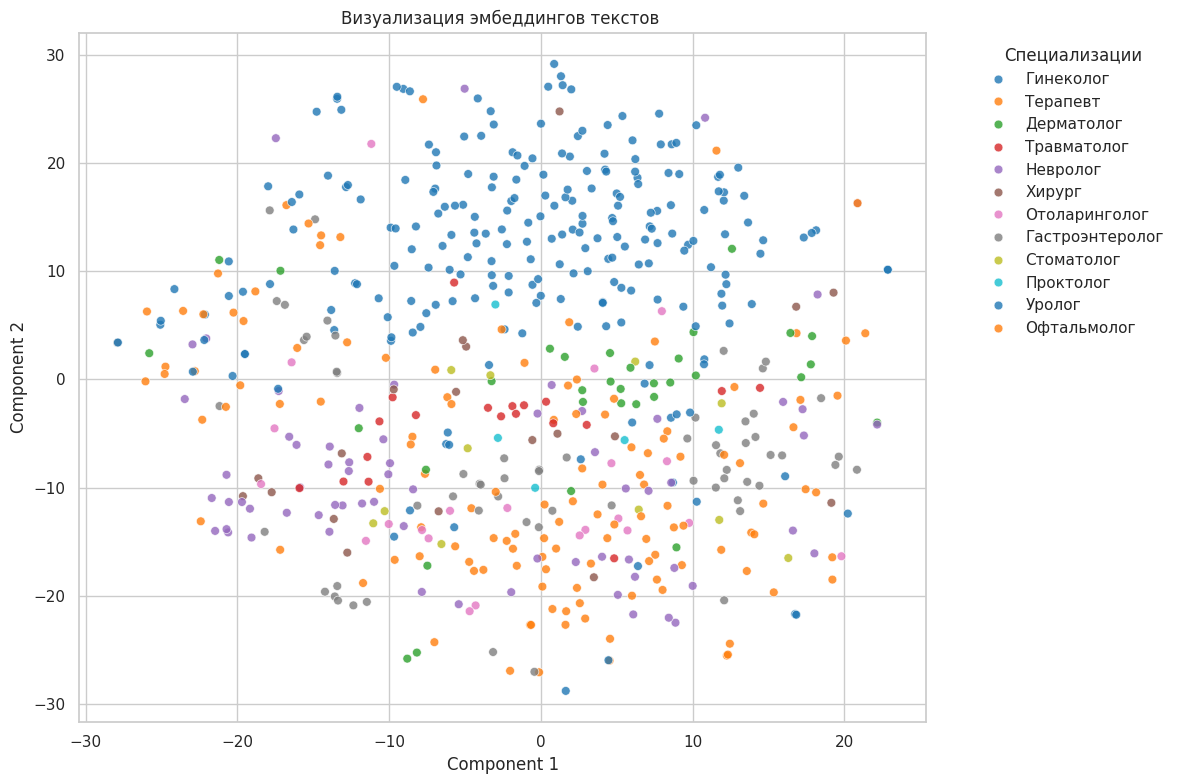

In [ ]:
# === ВАШ КОД ЗДЕСЬ ===

from sentence_transformers import SentenceTransformer
from sklearn.manifold import TSNE

df_tsne = df.sample(n=min(600, len(df)), random_state=42).reset_index(drop=True)

model = SentenceTransformer('intfloat/multilingual-e5-base')
embeddings = model.encode(df_tsne['desc'].tolist(), convert_to_tensor=False, show_progress_bar=False)

tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)
embeddings_2d = tsne.fit_transform(np.array(embeddings))

plt.figure(figsize=(12, 8))
sns.scatterplot(
    x=embeddings_2d[:, 0],
    y=embeddings_2d[:, 1],
    hue=df_tsne['spec10'],
    palette='tab10',
    alpha=0.8,
    s=40
)

plt.title('Визуализация эмбеддингов текстов ')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Специализации')
plt.tight_layout()
plt.show()

# === КОНЕЦ ВАШЕГО КОДА ===


**Ваши выводы по графику:**

*На графике видно, что классы* Гинеколог и Травматолог образует наиболее плотное и изолированное облако точек, что говорит о наличии уникальной терминологии в жалобах.



## Задание 7. Выводы по стандартной части (3 балла)

Напишите краткое резюме проделанной работы.

**Что нужно отразить:**
1. С какими основными проблемами в данных вы столкнулись при очистке?
2. Какой метод дедупликации показался вам наиболее эффективным и почему?
3. Насколько хорошо LLM справилась с задачей разметки в zero-shot режиме? Ожидали ли вы результат лучше или хуже?



**Итоговые выводы:**

1. Основной трудностью стало наличие скрытых текстовых пустот (пропусков) в поле spec10, которые были записаны не как стандартные системные NaN/None.
2. Самым эффективным методом оказался Семантическое сходство (sentence-transformers). Обычное точное совпадение и даже нечеткий поиск ищут только одинаковые буквы, пробелы или опечатки. А эмбеддинги смогли определить когда люди перефразировали вопросы своими словами или использовали синонимы. Смысл у текстов оставался один и тот же, и только этот метод с порогом 0.95 смог их обнаружить.
3. Модель Qwen-2.5-7B через OpenRouter справилась вполне нормально. Если в вопросе были чёткие маркеры (например, про зубы или беременность), модель безошибочно отправляла к стоматологу или гинекологу. Но когда люди писали общие жалобы нейросеть начинала путаться.


# Часть 2. Продвинутая (50 баллов)

В этой части мы сфокусируемся на продвинутых техниках: генерации синтетических данных, улучшении промптов и гибридных схемах разметки. Все эти методы активно применяются в индустрии для создания качественных датасетов при ограниченном бюджете.

*Важно: Для заданий 8, 10 и 11 вам нужно сгенерировать в сумме не менее 1000 новых записей.*


## Задание 8. Синтетическая генерация (Self-Instruct) (10 баллов)

Часто реальных данных не хватает для покрытия всех возможных краевых случаев (edge cases). Метод Self-Instruct позволяет использовать сильную LLM для генерации новых примеров на основе небольшого количества seed-примеров.

**Что нужно сделать:**
1. Напишите промпт для LLM, который просит сгенерировать реалистичные жалобы пациентов для конкретной специализации. Промпт должен требовать разнообразия в стиле (короткие, длинные, с ошибками, сленг).
2. Сгенерируйте не менее **300 новых примеров** для разных специализаций (равномерно распределите по классам).
3. Сохраните результаты.
4. Возьмите небольшую выборку синтетических данных и прогоните через вашу zero-shot классификацию из Задания 5. Сравните качество классификации на реальных и синтетических данных.


In [ ]:
# === ВАШ КОД ЗДЕСЬ ===

# === КОНЕЦ ВАШЕГО КОДА ===


## Задание 9. Улучшение разметки (few-shot) (8 баллов)

Zero-shot разметка часто ошибается на сложных примерах. Добавление нескольких качественных примеров в промпт (few-shot) может значительно улучшить результат.

**Что нужно сделать:**
1. Разработайте few-shot промпт. Добавьте в него по 1-2 хороших примера жалоб для каждой специализации.
2. Прогоните ваш `golden_set` (из Задания 5) через новый few-shot промпт.
3. Посчитайте метрики (Accuracy, F1-macro) и сравните их с результатами zero-shot.
4. Проведите анализ ошибок: посмотрите на 3-5 примеров, где few-shot модель ошиблась. Как вы думаете, почему это произошло?


In [ ]:
# === ВАШ КОД ЗДЕСЬ ===

# === КОНЕЦ ВАШЕГО КОДА ===


**Анализ ошибок:**

*Модель ошиблась на примерах... Я думаю это связано с тем, что...*



## Задание 10. Оценка уверенности LLM (10 баллов)

При автоматической разметке важно понимать, когда модель не уверена в своем ответе. Такие примеры лучше отправить на ручную проверку асессорам (human-in-the-loop).

Уверенность можно оценить различными способами:
- Запросить у API `logprobs` (вероятности токенов) для токенов ответа для подсчета **перплексии ответа**. Важно, далеко не все API сервисы возвращают logprobs, изучайте их документацию.
- Использовать sampling (temperature > 0.7): сгенерировать ответ 5 раз для одного промпта. Если все 5 раз класс совпадает — уверенность высокая. Если ответы разные — низкая. В том числе возможно использование beam search.

**Что нужно сделать:**
1. Реализуйте один из методов оценки уверенности.
2. Сгенерируйте или разметьте не менее **300 новых примеров** с обязательной фиксацией показателя уверенности (confidence score).
3. Постройте гистограмму распределения уверенности модели.
4. Выведите 3 примера с самой низкой уверенностью. Действительно ли они сложные/неоднозначные?


In [ ]:
# === ВАШ КОД ЗДЕСЬ ===

# === КОНЕЦ ВАШЕГО КОДА ===


## Задание 11. Гибридная схема разметки (10 баллов)

В реальных проектах разметка LLM стоит денег, а ручная разметка — еще больше денег и времени. Оптимальный подход: LLM размечает простые примеры (где ее уверенность высока), а сложные отправляются людям.

**Что нужно сделать:**
1. Сгенерируйте/разметьте еще не менее **400 примеров** (чтобы в сумме за Часть 2 получилось >= 1000 записей).
2. Напишите функцию симуляции "шумного" ручного разметчика. Эта функция принимает истинную метку и с вероятностью 95% возвращает ее, а с вероятностью 5% совершает ошибку (возвращает случайный другой класс).
3. Постройте гибридный пайплайн:
   - Если уверенность LLM выше порога `T`, принимаем метку LLM.
   - Если ниже `T`, отправляем "человеку" (используем симуляцию из п.2).
4. Проведите эксперимент с разными значениями порога `T`. Постройте график: по оси X — порог `T`, по оси Y две линии — итоговая Accuracy датасета и доля примеров, отправленных человеку.
5. Выберите оптимальный порог и обоснуйте выбор.


In [ ]:
# === ВАШ КОД ЗДЕСЬ ===

# === КОНЕЦ ВАШЕГО КОДА ===


**Обоснование выбора порога:**

*Оптимальный порог T=... потому что...*



## Задание 12. Публикация датасета на HuggingFace (7 баллов)

Итоговый результат вашей работы — это готовый набор данных, который можно использовать для обучения моделей. Отличная практика — делиться своими датасетами с сообществом, снабжая их подробной документацией (Dataset Card).

**Что нужно сделать:**
1. Соберите все сгенерированные и размеченные вами данные из Части 2 (не менее 1000 записей) в единый датасет формата HuggingFace `datasets`.
2. Загрузите датасет на свой аккаунт HuggingFace Hub (сделайте его публичным).
3. Напишите подробную **Dataset Card** (файл `README.md` в репозитории датасета).
4. Вставьте ссылку на ваш датасет в ячейку ниже.

**Требования к Dataset Card:**
- Описание задачи (для чего нужен датасет).
- Описание процесса генерации (какие модели использовались, как собирался).
- Численные показатели (размер датасета, распределение классов).
- Минимум 1 визуализация (например, сохраненный график распределения классов или t-SNE, загруженный как картинка).
- Примеры данных.


In [ ]:
# === ВАШ КОД ЗДЕСЬ ===
# Для загрузки можно использовать метод dataset.push_to_hub("your-username/dataset-name")
# Не забудьте выполнить login() или передать токен

# ССЫЛКА НА ВАШ ДАТАСЕТ: https://huggingface.co/datasets/...

# === КОНЕЦ ВАШЕГО КОДА ===


## Задание 13. Итоговые выводы (5 баллов)

Поздравляем, вы прошли полный цикл создания датасета для дообучения LLM! Напишите развернутые итоговые выводы по всей проделанной работе.

**Что нужно отразить:**
1. Сравните эффективность zero-shot, few-shot и гибридной стратегий разметки.
2. Дайте рекомендации: в каком случае (какой бюджет, какие требования к качеству) вы бы выбрали каждую из стратегий в реальном проекте?
3. Какие ограничения есть у метода генерации синтетических данных (Self-Instruct)? Заметили ли вы эффект однообразия в сгенерированных примерах?



**Итоговые выводы:**

*...*

